# Lvy — Lighting Enhancement Pipeline
## Fixed 600-image training / 150-image test experiment

**Resize 224 × 224 → Median Filter 3 × 3 → CLAHE → HSV Histogram → Random Forest**

This notebook keeps only Lvy's pipeline and uses the renamed `dataset` folder.
All tables, figures, predictions, and UI results are displayed in this notebook only.
No CSV, PDF, PNG, or trained-model files are exported to the project folder.


## Step 0 — Setup

The notebook uses the `dataset` folder inside `Mango_Ripeness_Final` and keeps all results in memory.
Run **Kernel → Restart Kernel and Run All** in Anaconda Jupyter.


In [1]:
from __future__ import annotations
from pathlib import Path
from typing import Dict, Tuple
import hashlib
import json
import re
import tempfile
import sys
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import sklearn
from scipy.optimize import Bounds, LinearConstraint, milp
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
)
from IPython.display import Markdown, display, clear_output

PROJECT_ROOT = Path(r'D:\Degree\Year 2\Sem 3\Image Processing\Mango_Ripeness_Final')
DATASET_ROOT = PROJECT_ROOT / 'dataset'
if not DATASET_ROOT.is_dir():
    raise FileNotFoundError(f'Dataset folder was not found: {DATASET_ROOT}')

RANDOM_STATE = 7
LABELS = ['Unripe', 'Partially Ripe', 'Ripe']
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
FEATURE_NAMES = [f'hsv_hist_{i:03d}' for i in range(96)]
RF_PARAMS = dict(
    n_estimators=50, max_features='sqrt', min_samples_leaf=2,
    criterion='gini', max_depth=8, bootstrap=True,
    random_state=RANDOM_STATE, n_jobs=-1,
)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})
print('Dataset folder:', DATASET_ROOT)
print('Outputs: displayed in this notebook only (no files exported)')
print('Random state:', RANDOM_STATE)
print('Classifier: Random Forest (50 trees)')


Dataset folder: D:\Degree\Year 2\Sem 3\Image Processing\Mango_Ripeness_Final\dataset
Outputs: displayed in this notebook only (no files exported)
Random state: 7
Classifier: Random Forest (50 trees)


### Original dataset and feature functions
The functions below are copied unchanged from the existing notebook. They compute each image's features independently.
No foreground mask is applied: this experiment uses the original full-image HSV histograms.

In [2]:
def canonical_label(value: str) -> str:
    text = re.sub(r"[_-]+", " ", str(value).strip().lower())
    text = re.sub(r"\s+", " ", text)
    if "partial" in text:
        return "Partially Ripe"
    if "unripe" in text or text == "un ripe":
        return "Unripe"
    if text == "ripe" or text.endswith(" ripe"):
        return "Ripe"
    return str(value).strip()


def infer_label(path: Path, root: Path) -> str:
    for folder in [path.parent, *path.parents]:
        label = canonical_label(folder.name)
        if label in LABELS:
            return label
        if folder == root:
            break
    return canonical_label(path.parent.name)


def infer_group_id(path: Path) -> str:
    """Use the original numeric ID, removing duplicate suffixes in brackets."""
    stem = path.stem.upper()
    stem = re.sub(r"\(\d+\)$", "", stem)
    stem = re.sub(r"(?:[_-](?:A|B))$", "", stem)
    stem = re.sub(r"(?:\s+)(?:A|B)$", "", stem)
    return stem


def collect_metadata(root: str | Path) -> pd.DataFrame:
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"Dataset directory does not exist: {root}")
    paths = sorted(
        p for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )
    if not paths:
        raise FileNotFoundError(f"No image files found below: {root}")
    frame = pd.DataFrame(
        {
            "path": [str(p) for p in paths],
            "label": [infer_label(p, root) for p in paths],
            "group": [infer_group_id(p) for p in paths],
        }
    )
    return frame


def preprocess_lvy(image_path: str | Path, image_size: Tuple[int, int] = (224, 224)) -> Dict[str, np.ndarray]:
    image_bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image_bgr is None:
        raise ValueError(f"Could not read image: {image_path}")

    resized = cv2.resize(image_bgr, image_size, interpolation=cv2.INTER_AREA)
    median = cv2.medianBlur(resized, 3)

    # CLAHE is applied to the V channel so that colour hue is not distorted.
    hsv_before = cv2.cvtColor(median, cv2.COLOR_BGR2HSV)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    hsv_after = hsv_before.copy()
    hsv_after[:, :, 2] = clahe.apply(hsv_before[:, :, 2])
    clahe_bgr = cv2.cvtColor(hsv_after, cv2.COLOR_HSV2BGR)
    hsv = cv2.cvtColor(clahe_bgr, cv2.COLOR_BGR2HSV)
    return {
        "resized": resized,
        "median": median,
        "clahe_bgr": clahe_bgr,
        "hsv": hsv,
    }


def hsv_histogram_features(image_path: str | Path, bins: int = 32) -> np.ndarray:
    hsv = preprocess_lvy(image_path)["hsv"]
    ranges = [(0, 180), (0, 256), (0, 256)]
    parts = []
    for channel, (low, high) in enumerate(ranges):
        hist = cv2.calcHist([hsv], [channel], None, [bins], [low, high]).ravel().astype(np.float32)
        hist /= max(float(hist.sum()), 1.0)
        parts.append(hist)
    return np.concatenate(parts)


def build_feature_table(metadata: pd.DataFrame, bins: int = 32) -> pd.DataFrame:
    rows = []
    for count, (_, row) in enumerate(metadata.iterrows(), start=1):
        vector = hsv_histogram_features(row["path"], bins=bins)
        item = {f"hsv_hist_{i:03d}": float(value) for i, value in enumerate(vector)}
        item.update({"path": row["path"], "label": row["label"], "group": row["group"]})
        rows.append(item)
        if count % 100 == 0:
            print(f"Extracted HSV histograms for {count}/{len(metadata)} images")
    return pd.DataFrame(rows)

## Step 1 — Resize Image
Resize to 224 × 224 pixels using the existing function.

In [3]:
# ==============================
# STEP 1 - RESIZE IMAGE
# ==============================
import cv2
import numpy as np

def STEP_1_RESIZE_IMAGE(image_path, image_size=(224, 224)):
    # Read the original image.
    original_image = cv2.imread(str(image_path))
    if original_image is None:
        raise ValueError(f'Cannot read image: {image_path}')

    # Make every image the same size.
    resized_image = cv2.resize(original_image, image_size, interpolation=cv2.INTER_AREA)
    return resized_image

## Step 2 — Median Filter
Apply the existing 3 × 3 median filter.

In [4]:
# ==============================
# STEP 2 - MEDIAN FILTER
# ==============================
def STEP_2_MEDIAN_FILTER(resized_image, kernel_size=3):
    # Remove small noise while keeping mango edges.
    median_image = cv2.medianBlur(resized_image, kernel_size)
    return median_image

## Step 3 — CLAHE
Apply CLAHE to the HSV Value channel: clip limit 2.0, tile grid 8 × 8.

In [5]:
# ==============================
# STEP 3 - CLAHE
# ==============================
def STEP_3_CLAHE(median_image):
    # Convert to HSV so CLAHE can improve brightness locally.
    hsv_image = cv2.cvtColor(median_image, cv2.COLOR_BGR2HSV)

    # Apply CLAHE only to the Value channel so the hue is preserved.
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    hsv_image[:, :, 2] = clahe.apply(hsv_image[:, :, 2])

    # Convert back to BGR for the next step.
    clahe_image = cv2.cvtColor(hsv_image, cv2.COLOR_HSV2BGR)
    return clahe_image

## Step 4 — HSV Histogram Feature Extraction
The existing function produces three normalized 32-bin histograms: H + S + V = 96 features.

In [6]:
# ==========================================
# STEP 4 - HSV HISTOGRAM FEATURE EXTRACTION
# ==========================================
def STEP_4_HSV_HISTOGRAM(clahe_image, bins=32):
    # Convert the enhanced image to HSV.
    hsv_image = cv2.cvtColor(clahe_image, cv2.COLOR_BGR2HSV)
    channel_ranges = [(0, 180), (0, 256), (0, 256)]
    histogram_features = []

    # Extract one normalized histogram for H, S, and V.
    for channel, (low, high) in enumerate(channel_ranges):
        histogram = cv2.calcHist([hsv_image], [channel], None, [bins], [low, high])
        histogram = histogram.flatten().astype(np.float32)
        histogram = histogram / max(float(histogram.sum()), 1.0)
        histogram_features.extend(histogram)

    # 32 Hue + 32 Saturation + 32 Value = 96 features.
    return np.asarray(histogram_features, dtype=np.float32)

## Step 5 — Random Forest
This training function receives only the 600 training feature vectors. The fixed parameters are inherited from the original model.

In [7]:
def STEP_5_TRAIN_RANDOM_FOREST(X_train, y_train):
    assert X_train.shape == (600, 96)
    assert len(y_train) == 600
    model = RandomForestClassifier(**RF_PARAMS)
    model.fit(X_train, y_train)
    return model

display(pd.DataFrame(
    list(RF_PARAMS.items()), columns=['Random Forest parameter', 'Value']
))

,Random Forest parameter,Value
0,n_estimators,50
1,max_features,sqrt
2,min_samples_leaf,2
3,criterion,gini
4,max_depth,8
5,bootstrap,True
6,random_state,7
7,n_jobs,-1


# Main Chapter 4 Evaluation – Random Forest with 150 Test Images
## 1. Dataset inventory and exact stratified group split

The dataset must contain 750 images, with 250 per class.

**Fixed split procedure (random_state = 42):**

1. Reuse the original filename-derived mango group IDs. Assign each group a majority class for the initial stratified random group sample.
2. Adjust whole groups using integer constraints until the test set contains exactly 50 images of each actual class. Minimize the number of group assignments changed; a seeded tie-break makes the selection reproducible.
3. Save the exact assignment in a split manifest and reuse it on later runs.

The allocation uses only labels and groups. Model predictions and feature values play no part in selecting it.
Group IDs are filename proxies inherited from the old notebook, not verified biological identities. Groups carrying multiple labels are kept together.

In [8]:
metadata = collect_metadata(DATASET_ROOT).reset_index(drop=True)
metadata['relative_path'] = [
    Path(path).relative_to(DATASET_ROOT).as_posix() for path in metadata['path']
]
assert metadata['relative_path'].is_unique, 'Repeated image paths found.'
assert len(metadata) == 750, f'Expected 750 images, found {len(metadata)}.'
assert set(metadata['label']) == set(LABELS)
assert metadata['label'].value_counts().reindex(LABELS).tolist() == [250, 250, 250]

def make_fixed_stratified_group_split(frame, random_state=7):
    group_counts = pd.crosstab(frame['group'], frame['label']).reindex(
        columns=LABELS, fill_value=0
    ).sort_index()
    majority_labels = group_counts.idxmax(axis=1)
    _, initial_test_groups = train_test_split(
        np.arange(len(group_counts)), test_size=0.20,
        stratify=majority_labels, random_state=random_state,
    )
    initial = np.zeros(len(group_counts))
    initial[initial_test_groups] = 1
    rng = np.random.default_rng(random_state)
    costs = (1 - 2 * initial) + rng.uniform(0, 0.001, len(group_counts))
    target = np.full(len(LABELS), 50)
    solution = milp(
        c=costs,
        integrality=np.ones(len(group_counts)),
        bounds=Bounds(0, 1),
        constraints=LinearConstraint(group_counts.to_numpy().T, target, target),
        options={'time_limit': 60, 'mip_rel_gap': 0},
    )
    if not solution.success:
        raise RuntimeError('Cannot create the exact group-disjoint 50/50/50 test set: ' + solution.message)
    selected_groups = set(group_counts.index[solution.x > 0.5])
    return np.where(frame['group'].isin(selected_groups), 'test', 'train')

metadata['split'] = make_fixed_stratified_group_split(metadata, RANDOM_STATE)
train_indices = np.flatnonzero(metadata['split'].eq('train').to_numpy())
test_indices = np.flatnonzero(metadata['split'].eq('test').to_numpy())
train_metadata = metadata.iloc[train_indices].copy()
test_metadata = metadata.iloc[test_indices].copy()
train_groups = set(train_metadata['group'])
test_groups = set(test_metadata['group'])
assert len(train_indices) == 600 and len(test_indices) == 150
assert not (train_groups & test_groups), 'Mango group leakage found.'
assert train_metadata['label'].value_counts().reindex(LABELS).tolist() == [200, 200, 200]
assert test_metadata['label'].value_counts().reindex(LABELS).tolist() == [50, 50, 50]

split_distribution = pd.DataFrame({
    'Ripeness Class': LABELS,
    'Full dataset': [250] * 3,
    'Training images': train_metadata['label'].value_counts().reindex(LABELS).to_numpy(),
    'Test images': test_metadata['label'].value_counts().reindex(LABELS).to_numpy(),
})
display(split_distribution)
print('Split fixed before model fitting: 600 training images and 150 test images.')
print('Group overlap between training and testing:', len(train_groups & test_groups))


,Ripeness Class,Full dataset,Training images,Test images
0,Unripe,250,200,50
1,Partially Ripe,250,200,50
2,Ripe,250,200,50


Split fixed before model fitting: 600 training images and 150 test images.
Group overlap between training and testing: 0


## 2. Run Steps 1–4 and prepare feature vectors
Features are extracted with the original functions from the actual images. A new cache tracks image paths, sizes, timestamps and pipeline settings.
Calculating a histogram on a test image does not train the classifier; only the 600 training rows will enter `fit()`.

In [9]:
PIPELINE_DESCRIPTION = (
    'Resize 224x224 -> Median Filter 3x3 -> CLAHE (V, clipLimit=2.0, grid=8x8)'
    ' -> full-image HSV histograms (32+32+32 bins, normalized) -> Random Forest'
)
fingerprint_source = {
    'pipeline': PIPELINE_DESCRIPTION,
    'files': [
        [row.relative_path, Path(row.path).stat().st_size, Path(row.path).stat().st_mtime_ns]
        for row in metadata.itertuples()
    ],
}
feature_fingerprint = hashlib.sha256(
    json.dumps(fingerprint_source, sort_keys=True).encode('utf-8')
).hexdigest()
features = build_feature_table(metadata, bins=32)
features['relative_path'] = metadata['relative_path'].to_numpy()
print('Extracted HSV histogram features in memory; no feature cache was written.')

assert features['label'].tolist() == metadata['label'].tolist()
assert features['group'].astype(str).tolist() == metadata['group'].astype(str).tolist()
X = features[FEATURE_NAMES].to_numpy(dtype=np.float32)
assert X.shape == (750, 96) and np.isfinite(X).all()
np.testing.assert_allclose(X.reshape(-1, 3, 32).sum(axis=2), 1, atol=1e-5)
X_train, X_test = X[train_indices], X[test_indices]
y_train = metadata.iloc[train_indices]['label'].to_numpy()
y_test = metadata.iloc[test_indices]['label'].to_numpy()
print('Training feature matrix:', X_train.shape)
print('Test feature matrix:', X_test.shape)
print('Feature extraction:', PIPELINE_DESCRIPTION)


Extracted HSV histograms for 100/750 images
Extracted HSV histograms for 200/750 images
Extracted HSV histograms for 300/750 images
Extracted HSV histograms for 400/750 images
Extracted HSV histograms for 500/750 images
Extracted HSV histograms for 600/750 images
Extracted HSV histograms for 700/750 images
Extracted HSV histogram features in memory; no feature cache was written.
Training feature matrix: (600, 96)
Test feature matrix: (150, 96)
Feature extraction: Resize 224x224 -> Median Filter 3x3 -> CLAHE (V, clipLimit=2.0, grid=8x8) -> full-image HSV histograms (32+32+32 bins, normalized) -> Random Forest


Extracted HSV histograms for 200/750 images


Extracted HSV histograms for 300/750 images


Extracted HSV histograms for 400/750 images


Extracted HSV histograms for 500/750 images


Extracted HSV histograms for 600/750 images


Extracted HSV histograms for 700/750 images


Extracted HSV histogram features in memory; no feature cache was written.
Training feature matrix: (600, 96)
Test feature matrix: (150, 96)
Feature extraction: Resize 224x224 -> Median Filter 3x3 -> CLAHE (V, clipLimit=2.0, grid=8x8) -> full-image HSV histograms (32+32+32 bins, normalized) -> Random Forest


## 3. Train Random Forest on 600 images and predict 150 test images
There is one fixed fit. All Chapter 4 metrics below use `y_test` and `y_pred` from this cell.

In [10]:
chapter4_model = STEP_5_TRAIN_RANDOM_FOREST(X_train, y_train)
y_pred = chapter4_model.predict(X_test)
test_probabilities = chapter4_model.predict_proba(X_test)
assert len(y_pred) == len(y_test) == 150
print('Model trained using 600 images only.')
print('Predictions made for 150 held-out test images.')
print('Random Forest parameters:', RF_PARAMS)

Model trained using 600 images only.
Predictions made for 150 held-out test images.
Random Forest parameters: {'n_estimators': 50, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'criterion': 'gini', 'max_depth': 8, 'bootstrap': True, 'random_state': 7, 'n_jobs': -1}


## 4. Overall Classification Performance
Precision, Recall and F1-score use **macro averaging** (equal weight per class).

In [11]:
accuracy = float(accuracy_score(y_test, y_pred))
precision = float(precision_score(y_test, y_pred, labels=LABELS, average='macro', zero_division=0))
recall = float(recall_score(y_test, y_pred, labels=LABELS, average='macro', zero_division=0))
f1 = float(f1_score(y_test, y_pred, labels=LABELS, average='macro', zero_division=0))
correct_count = int(np.count_nonzero(y_pred == y_test))
incorrect_count = int(len(y_test) - correct_count)
for name, value in [('Accuracy', accuracy), ('Precision', precision), ('Recall', recall), ('F1-score', f1)]:
    print(f'{name:<9}: {value:.4f} ({value:.2%})')
print(f'Correct predictions: {correct_count} / 150')
print(f'Incorrect predictions: {incorrect_count} / 150')

chapter4_overall_metrics = pd.DataFrame({
    'Evaluation Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Score': [accuracy, precision, recall, f1],
    'Percentage (%)': [100 * value for value in [accuracy, precision, recall, f1]],
})
display(chapter4_overall_metrics.style.format({'Score': '{:.4f}', 'Percentage (%)': '{:.2f}'}))

Accuracy : 0.9333 (93.33%)
Precision: 0.9351 (93.51%)
Recall   : 0.9333 (93.33%)
F1-score : 0.9334 (93.34%)
Correct predictions: 140 / 150
Incorrect predictions: 10 / 150


,Evaluation Metric,Score,Percentage (%)
0,Accuracy,0.9333,93.33
1,Precision,0.9351,93.51
2,Recall,0.9333,93.33
3,F1-score,0.9334,93.34


## 5. Class-Level Results
Class order: Unripe → Partially Ripe → Ripe. Support is exactly 50 for every class.

In [12]:
class_report = classification_report(
    y_test, y_pred, labels=LABELS, target_names=LABELS,
    output_dict=True, zero_division=0,
)
class_report_df = pd.DataFrame([
    {
        'Ripeness Class': label,
        'Precision': class_report[label]['precision'],
        'Recall': class_report[label]['recall'],
        'F1-score': class_report[label]['f1-score'],
        'Support': int(class_report[label]['support']),
    } for label in LABELS
])
assert class_report_df['Support'].tolist() == [50, 50, 50]
display(class_report_df.style.format({
    'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1-score': '{:.4f}', 'Support': '{:d}',
}))

,Ripeness Class,Precision,Recall,F1-score,Support
0,Unripe,0.9423,0.9800,0.9608,50
1,Partially Ripe,0.8846,0.9200,0.9020,50
2,Ripe,0.9783,0.9000,0.9375,50


## 6. Confusion Matrix
Rows are actual classes; columns are predicted classes. The matrix contains only the 150 test predictions.

Class order: ['Unripe', 'Partially Ripe', 'Ripe']
Raw numerical confusion matrix:
[[49  1  0]
 [ 3 46  1]
 [ 0  5 45]]


Predicted Class,Unripe,Partially Ripe,Ripe
Actual Class,,,
Unripe,49,1,0
Partially Ripe,3,46,1
Ripe,0,5,45


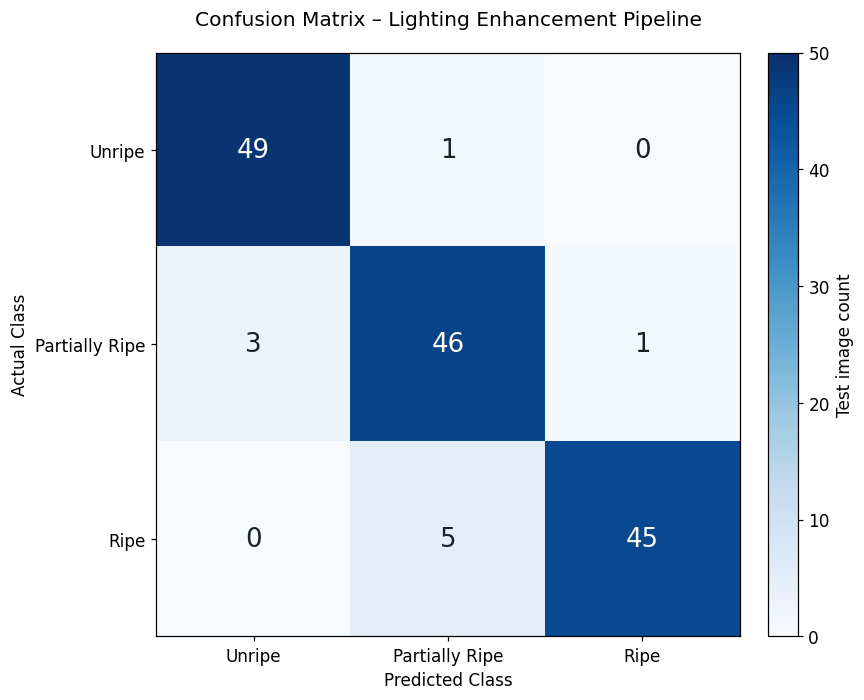

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=LABELS)
assert int(cm.sum()) == 150
assert cm.sum(axis=1).tolist() == [50, 50, 50]
assert int(np.trace(cm)) == correct_count
print('Class order:', LABELS)
print('Raw numerical confusion matrix:')
print(cm)
confusion_matrix_df = pd.DataFrame(
    cm, index=pd.Index(LABELS, name='Actual Class'),
    columns=pd.Index(LABELS, name='Predicted Class'),
)
display(confusion_matrix_df)

def display_report_figure(figure, basename=None):
    display(figure)
    plt.close(figure)

fig, ax = plt.subplots(figsize=(8, 6.5))
heatmap = ax.imshow(cm, cmap='Blues', vmin=0, vmax=50)
ax.set_xticks(range(3), LABELS)
ax.set_yticks(range(3), LABELS)
ax.set_xlabel('Predicted Class')
ax.set_ylabel('Actual Class')
ax.set_title('Confusion Matrix – Lighting Enhancement Pipeline', pad=18)
for i in range(3):
    for j in range(3):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                fontsize=17, color='white' if cm[i, j] > 25 else '#17212b')
fig.colorbar(heatmap, ax=ax, label='Test image count', fraction=0.046, pad=0.04)
fig.tight_layout()
display_report_figure(fig, 'chapter4_confusion_matrix')


## 7. Performance Bar Chart
Scores are percentages from the 150-image test set.

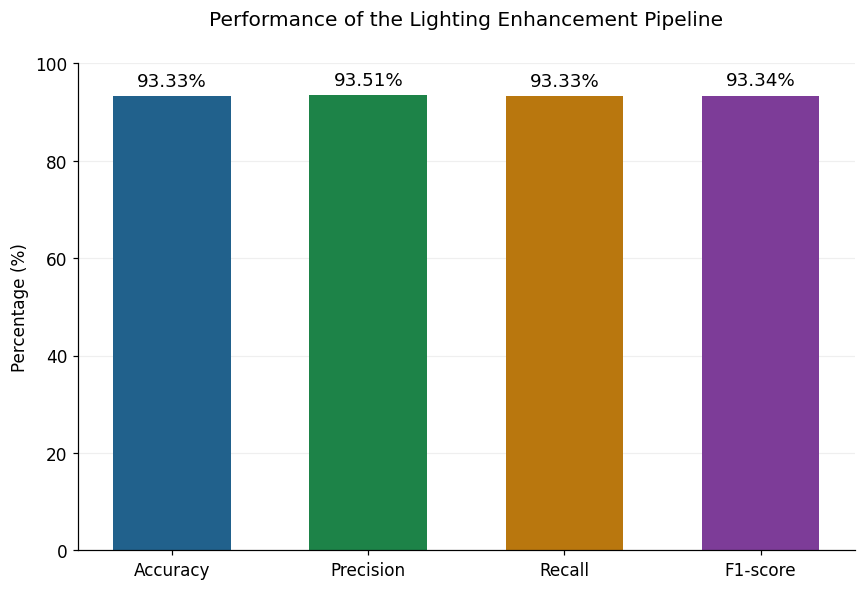

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.5))
values = chapter4_overall_metrics['Percentage (%)'].to_numpy()
bars = ax.bar(
    chapter4_overall_metrics['Evaluation Metric'], values,
    color=['#21618c', '#1d8348', '#b9770e', '#7d3c98'], width=0.6,
)
ax.set_title('Performance of the Lighting Enhancement Pipeline', pad=25)
ax.set_ylabel('Percentage (%)')
ax.set_ylim(0, 100)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_yticks(np.arange(0, 101, 20))
ax.grid(axis='y', alpha=0.2)
ax.set_axisbelow(True)
for bar, value in zip(bars, values):
    ax.annotate(f'{value:.2f}%', (bar.get_x() + bar.get_width()/2, value),
                xytext=(0, 4), textcoords='offset points',
                ha='center', va='bottom', fontsize=12, annotation_clip=False)
fig.tight_layout()
display_report_figure(fig, 'chapter4_performance_bar_chart')

## 8. Correct Classification by Class and Misclassification Details
The counts come directly from the confusion matrix.

In [ ]:
correct_by_class_df = pd.DataFrame({
    'Ripeness Class': LABELS, 'Correct predictions': np.diag(cm), 'Test images': [50] * 3,
})
for label, correct in zip(LABELS, np.diag(cm)):
    print(f'{label}: {correct} / 50 correctly classified')

misclassification_rows = []
print('\nMISCLASSIFICATION COUNTS')
for i, actual in enumerate(LABELS):
    for j, predicted in enumerate(LABELS):
        if i != j:
            count = int(cm[i, j])
            print(f'Actual {actual} → Predicted {predicted}: {count}')
            misclassification_rows.append({
                'Actual Class': actual, 'Predicted Class': predicted, 'Count': count,
            })
misclassification_counts_df = pd.DataFrame(misclassification_rows)
assert int(misclassification_counts_df['Count'].sum()) == incorrect_count
display(misclassification_counts_df)

test_predictions_df = test_metadata[['relative_path', 'label', 'group']].reset_index(drop=True)
test_predictions_df = test_predictions_df.rename(columns={'label': 'Actual Class'})
test_predictions_df['Predicted Class'] = y_pred
test_predictions_df['Correct'] = y_pred == y_test
for j, label in enumerate(chapter4_model.classes_):
    test_predictions_df[f'RF probability - {label}'] = test_probabilities[:, j]
misclassified_images_df = test_predictions_df.loc[~test_predictions_df['Correct']].copy()
print(f'All misclassified test image files ({len(misclassified_images_df)}):')
display(misclassified_images_df)

## 9. Save Main Chapter 4 Results
Tables, figures, the split manifest, all 150 predictions, and the model fitted on 600 training images are saved in the Chapter 4 folder.

In [ ]:
chapter4_results = {
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'f1_score': f1,
    'correct_predictions': correct_count,
    'incorrect_predictions': incorrect_count,
    'train_size': len(train_indices),
    'test_size': len(test_indices),
    'class_report': class_report_df,
    'confusion_matrix': cm,
}
display(Markdown('### In-memory result object'))
display(pd.DataFrame([
    ('Accuracy', f'{accuracy:.4f} ({accuracy:.2%})'),
    ('Macro Precision', f'{precision:.4f} ({precision:.2%})'),
    ('Macro Recall', f'{recall:.4f} ({recall:.2%})'),
    ('Macro F1-score', f'{f1:.4f} ({f1:.2%})'),
    ('Correct predictions', f'{correct_count} / 150'),
    ('Random state', RANDOM_STATE),
], columns=['Metric', 'Result']))


## 10. Final Verification Summary
These are the main fixed train-test results, not the original 5-fold scores.

In [ ]:
verification_summary = pd.DataFrame([
    ('Training images', 600),
    ('Test images', 150),
    ('Unripe test images', 50),
    ('Partially Ripe test images', 50),
    ('Ripe test images', 50),
    ('Classifier', 'RandomForestClassifier'),
    ('Random Forest settings', str(RF_PARAMS)),
    ('Accuracy', f'{accuracy:.4f} ({accuracy:.2%})'),
    ('Macro Precision', f'{precision:.4f} ({precision:.2%})'),
    ('Macro Recall', f'{recall:.4f} ({recall:.2%})'),
    ('Macro F1-score', f'{f1:.4f} ({f1:.2%})'),
    ('Correct predictions', f'{correct_count} / 150'),
    ('Overlapping mango group IDs', len(train_groups & test_groups)),
], columns=['Verification Item', 'Result'])
display(verification_summary)
print('All scores use exactly 150 held-out test predictions.')
print('No test features or labels were passed to Random Forest.fit().')


## 11. Show Each Pipeline Step and Explain an Image Prediction
The display uses the same model fitted on the 600 training images. Reference tables use **only those training images**.

HSV values below are approximate linear means reconstructed from histogram bins, including the background because this is the original full-image pipeline. Hue is circular; a mean is only a compact descriptive summary. The displayed ranges are training-image quartiles, not universal ripeness thresholds.

Random Forest uses its decision trees and all 96 bins. Distance to a class's average histogram is a separate descriptive comparison, not the Random Forest decision rule. These displays help inspect a prediction; they do not establish that the predicted maturity is correct.

In [ ]:
def process_image_with_original_steps(image_path):
    original = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if original is None:
        raise ValueError(f'Cannot read image: {image_path}')
    resized = STEP_1_RESIZE_IMAGE(image_path)
    median = STEP_2_MEDIAN_FILTER(resized)
    clahe = STEP_3_CLAHE(median)
    vector = STEP_4_HSV_HISTOGRAM(clahe)
    return {
        'original': original, 'resized': resized, 'median': median,
        'clahe': clahe, 'hsv': cv2.cvtColor(clahe, cv2.COLOR_BGR2HSV),
        'features': vector,
    }

def make_pipeline_figure(stages, predicted_label):
    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    panels = [
        ('Input image', cv2.cvtColor(stages['original'], cv2.COLOR_BGR2RGB), None, None),
        ('Step 1 – Resize 224 × 224', cv2.cvtColor(stages['resized'], cv2.COLOR_BGR2RGB), None, None),
        ('Step 2 – Median Filter 3 × 3', cv2.cvtColor(stages['median'], cv2.COLOR_BGR2RGB), None, None),
        ('Step 3 – CLAHE (Value channel)', cv2.cvtColor(stages['clahe'], cv2.COLOR_BGR2RGB), None, None),
        ('Step 4 – Hue map', stages['hsv'][:, :, 0], 'hsv', 179),
        ('Step 4 – Saturation map', stages['hsv'][:, :, 1], 'gray', 255),
        ('Step 4 – Value map', stages['hsv'][:, :, 2], 'gray', 255),
    ]
    for ax, (title, pixels, cmap, vmax) in zip(axes.flat, panels):
        ax.imshow(pixels, cmap=cmap, vmin=0 if vmax else None, vmax=vmax)
        ax.set_title(title, fontsize=11)
        ax.axis('off')
    ax = axes.flat[7]
    for channel, name in enumerate(['H', 'S', 'V']):
        ax.plot(np.arange(32), stages['features'][channel*32:(channel+1)*32], label=name)
    ax.set_title('Step 4 – HSV Histograms (96 bins)', fontsize=11)
    ax.set_xlabel('Bin index (0–31 per channel)')
    ax.set_ylabel('Normalized frequency')
    ax.legend()
    ax = axes.flat[8]
    ax.axis('off')
    ax.text(0.5, 0.7, 'Step 5 – Random Forest', ha='center', fontsize=13, weight='bold')
    ax.text(0.5, 0.45, str(predicted_label), ha='center', fontsize=19, color='#21618c')
    ax.text(0.5, 0.25, 'Model fitted on 600 training images', ha='center', fontsize=10)
    fig.suptitle('Lvy – Lighting Enhancement Pipeline', fontsize=16)
    fig.tight_layout()
    return fig

hsv_centres = [(np.arange(32) + 0.5) * span / 32 for span in [180, 256, 256]]
train_hsv_means = np.column_stack([
    X_train[:, ch*32:(ch+1)*32] @ hsv_centres[ch] for ch in range(3)
])
reference_rows = []
for label in LABELS:
    rows = train_hsv_means[y_train == label]
    item = {'Ripeness Class': label, 'Training images': len(rows)}
    for ch, name in enumerate('HSV'):
        item[f'{name} median'] = float(np.median(rows[:, ch]))
        q1, q3 = np.quantile(rows[:, ch], [0.25, 0.75])
        item[f'{name} middle 50%'] = f'{q1:.2f} – {q3:.2f}'
    reference_rows.append(item)
training_hsv_reference = pd.DataFrame(reference_rows)

def show_prediction_with_steps(image_path):
    stages = process_image_with_original_steps(image_path)
    vector = stages['features']
    predicted = chapter4_model.predict(vector.reshape(1, -1))[0]
    probabilities = dict(zip(
        chapter4_model.classes_, chapter4_model.predict_proba(vector.reshape(1, -1))[0]
    ))
    fig = make_pipeline_figure(stages, predicted)
    display(fig)
    plt.close(fig)
    hsv_means = [float(vector[ch*32:(ch+1)*32] @ hsv_centres[ch]) for ch in range(3)]
    display(Markdown('**Input HSV summary (approximate binned means, full image)**'))
    display(pd.DataFrame([hsv_means], columns=['H (0–179)', 'S (0–255)', 'V (0–255)']).round(2))
    comparison = training_hsv_reference.copy()
    comparison['Histogram distance (descriptive)'] = [
        float(np.linalg.norm(vector - X_train[y_train == label].mean(axis=0)))
        for label in LABELS
    ]
    comparison['RF probability'] = [float(probabilities[label]) for label in LABELS]
    comparison['RF selected'] = ['Yes' if label == predicted else '' for label in LABELS]
    display(Markdown('**Training-class reference and model output**'))
    display(comparison.style.format({
        'H median': '{:.2f}', 'S median': '{:.2f}', 'V median': '{:.2f}',
        'Histogram distance (descriptive)': '{:.4f}', 'RF probability': '{:.2%}',
    }))
    print('Predicted ripeness:', predicted)
    print('RF probability is model output, not a measured chance of being correct.')
    print('HSV ranges and distances are descriptive; they are not RF rules or proof of correctness.')
    return predicted

# A saved pipeline demonstration, selected from TRAINING data before looking at predictions.
example_path = train_metadata.iloc[0]['path']
sample_steps = process_image_with_original_steps(example_path)
np.testing.assert_allclose(
    sample_steps['features'], hsv_histogram_features(example_path), atol=1e-7
)
print('Pipeline demonstration image:', Path(example_path).name, '(training example)')
_ = show_prediction_with_steps(example_path)

## 12. Jupyter UI — Upload Image and Predict
Upload one image, then click **Predict + Show Steps**. The UI displays the effects of every pipeline step and the training-class reference table.
These additional uploaded-image predictions do not enter the Chapter 4 scores above.

In [ ]:
import ipywidgets as widgets

chapter4_upload = widgets.FileUpload(accept='image/*', multiple=False, description='Choose image')
chapter4_predict_button = widgets.Button(
    description='Predict + Show Steps', button_style='success',
    layout=widgets.Layout(width='220px'),
)
chapter4_ui_output = widgets.Output()

def chapter4_on_predict(_button):
    with chapter4_ui_output:
        clear_output(wait=True)
        value = chapter4_upload.value
        if not value:
            print('Please choose a mango image first.')
            return
        info = next(iter(value.values())) if isinstance(value, dict) else value[0]
        try:
            print('Uploaded image:', info.get('name', 'image'))
            with tempfile.TemporaryDirectory(prefix='lvy_ch4_') as folder:
                image_path = Path(folder) / 'uploaded_image.img'
                image_path.write_bytes(bytes(info['content']))
                show_prediction_with_steps(image_path)
        except Exception as error:
            print(f'Could not process image: {error}')

chapter4_predict_button.on_click(chapter4_on_predict)
display(widgets.VBox([chapter4_upload, chapter4_predict_button, chapter4_ui_output]))